<a href="https://colab.research.google.com/github/iamKrishu1916/KAN-Kolmogorov-Arnold-Networks-for-learnable-activation-function./blob/main/notebooks/Bessel_Func.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN, create_dataset

checkpoint directory created: ./model
saving model version 0.0
Training on grid size 3...


| train_loss: 2.67e-01 | test_loss: 2.67e-01 | reg: 1.91e+00 | : 100%|█| 200/200 [00:09<00:00, 22.20


saving model version 0.1
Training on grid size 5...
saving model version 0.2


| train_loss: 2.14e-01 | test_loss: 2.09e-01 | reg: 2.27e+00 | : 100%|█| 200/200 [00:04<00:00, 45.47


saving model version 0.3
Training on grid size 10...
saving model version 0.4


...

saving model version 0.5
Training on grid size 20...
saving model version 0.6


| train_loss: 1.03e-02 | test_loss: 1.04e-02 | reg: 2.53e+00 | : 100%|█| 200/200 [00:03<00:00, 58.05


saving model version 0.7
Training on grid size 50...
saving model version 0.8


| train_loss: 3.19e-04 | test_loss: 8.70e-04 | reg: 2.53e+00 | : 100%|█| 200/200 [00:03<00:00, 52.26


saving model version 0.9


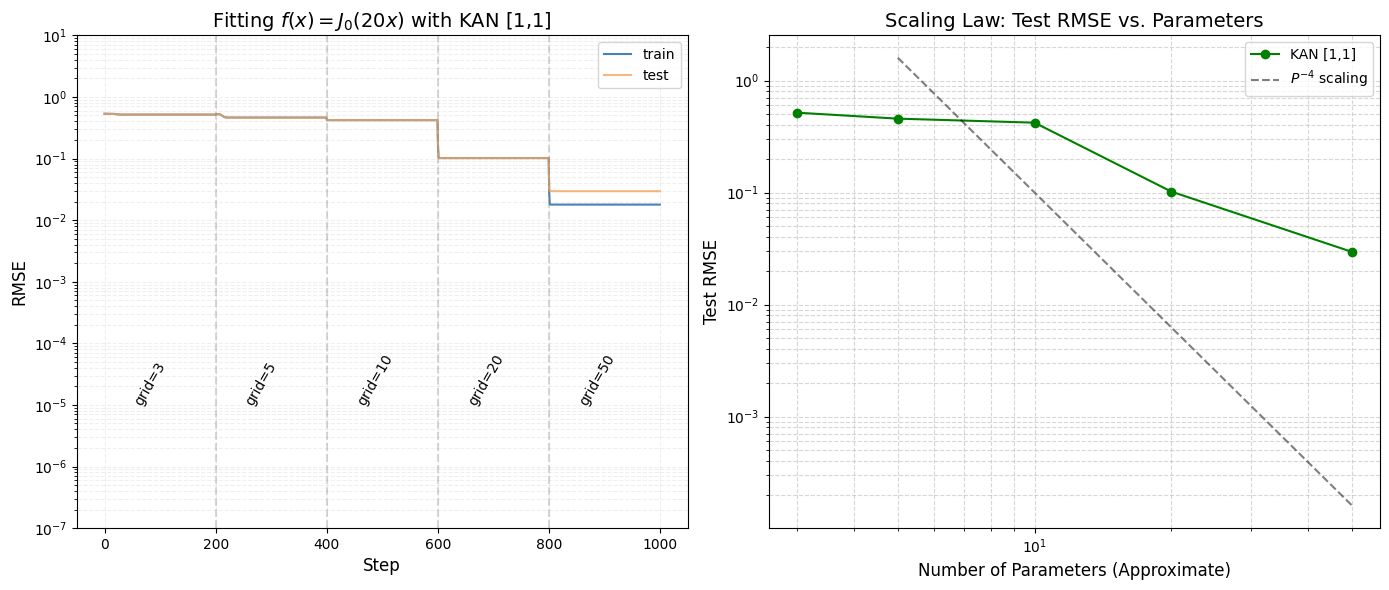

In [ ]:


# Force CPU and float64 for mathematical stability during spline interpolation
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

# 1. Define the synthetic dataset: f(x) = J_0(20x)
# Note: n_var=1 because this is a 1D function
f = lambda x: torch.special.bessel_j0(20 * x[:, [0]])
dataset = create_dataset(f, n_var=1, train_num=1000, test_num=1000, device=device)

# 2. Experiment Configuration
# Keeping the reduced compute limit (stops at 50).
# Expand to [..., 100, 200, 500, 1000] if you want to see the full paper curve!
grids = [3, 5, 10, 20, 50]
steps_per_grid = 200

# 3. Initialize Model and Storage
# Architecture is [1, 1] for a 1D -> 1D mapping
model = KAN(width=[1, 1], grid=grids[0], k=3, seed=0, device=device)

train_rmse = []
test_rmse = []
final_test_rmse = []

# 4. Training Loop with Grid Extension
for g in grids:
    print(f"Training on grid size {g}...")
    if g != grids[0]:
        # Fine-grain the spline grids
        model = model.refine(g)

    # lamb=0.0 disables sparsity regularization so LBFGS focuses purely on MSE
    res = model.fit(dataset, opt="LBFGS", steps=steps_per_grid, lamb=0.0)

    # PyKAN natively returns MSE; we take sqrt for RMSE
    train_rmse.extend(np.sqrt(res['train_loss']))

    # Store test loss step-by-step for the first plot, and final loss for the second plot
    test_rmse_step = np.sqrt(res['test_loss'])
    test_rmse.extend(test_rmse_step)
    final_test_rmse.append(test_rmse_step[-1])

# 5. Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Loss vs Steps (Training Dynamics) ---
steps_total = np.arange(len(grids) * steps_per_grid)

axs[0].semilogy(steps_total, train_rmse, label='train', color='steelblue', linewidth=1.5)
axs[0].semilogy(steps_total, test_rmse, label='test', color='sandybrown', linewidth=1.5, alpha=0.8)

# Add grid text annotations and vertical dividing lines
for i, g in enumerate(grids):
    axs[0].text(i * steps_per_grid + 50, 1e-5, f'grid={g}', rotation=60, fontsize=10)
    if i > 0:
        axs[0].axvline(x=i * steps_per_grid, color='gray', linestyle='--', alpha=0.3)

axs[0].set_title(r'Fitting $f(x) = J_0(20x)$ with KAN [1,1]', fontsize=14)
axs[0].set_xlabel('Step', fontsize=12)
axs[0].set_ylabel('RMSE', fontsize=12)
axs[0].set_ylim(1e-7, 1e1)
axs[0].legend(loc='upper right')
axs[0].grid(True, which="both", ls="--", alpha=0.2)

# --- Plot 2: Loss vs Parameters (Scaling Laws) ---
G = np.array(grids)
# A [1,1] KAN has exactly 1 edge. Parameters = 1 * G
params_11 = 1 * G

axs[1].loglog(params_11, final_test_rmse, 'g-o', label='KAN [1,1]', markersize=6)

# Add a reference scaling line to see how steeply it learns (e.g., P^-4)
ref_line = 1e3 * params_11**(-4.0)
axs[1].loglog(params_11[1:], ref_line[1:], 'k--', alpha=0.5, label='$P^{-4}$ scaling')

axs[1].set_title(r'Scaling Law: Test RMSE vs. Parameters', fontsize=14)
axs[1].set_xlabel('Number of Parameters (Approximate)', fontsize=12)
axs[1].set_ylabel('Test RMSE', fontsize=12)
axs[1].grid(True, which="both", ls="--", alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

### increasing the training epochs

checkpoint directory created: ./model
saving model version 0.0
Training on grid size 3...


| train_loss: 2.67e-01 | test_loss: 2.67e-01 | reg: 1.91e+00 | : 100%|█| 200/200 [00:04<00:00, 49.78


saving model version 0.1
Training on grid size 5...
saving model version 0.2


| train_loss: 2.14e-01 | test_loss: 2.09e-01 | reg: 2.27e+00 | : 100%|█| 200/200 [00:04<00:00, 42.26


saving model version 0.3
Training on grid size 10...
saving model version 0.4


...

saving model version 0.9
Training on grid size 100...
saving model version 0.10


| train_loss: 2.87e-05 | test_loss: 6.23e-03 | reg: 2.53e+00 | : 100%|█| 200/200 [00:06<00:00, 29.36


saving model version 0.11
Training on grid size 200...
saving model version 0.12


| train_loss: 3.23e-06 | test_loss: 4.96e-02 | reg: 2.53e+00 | : 100%|█| 200/200 [00:09<00:00, 20.14


saving model version 0.13


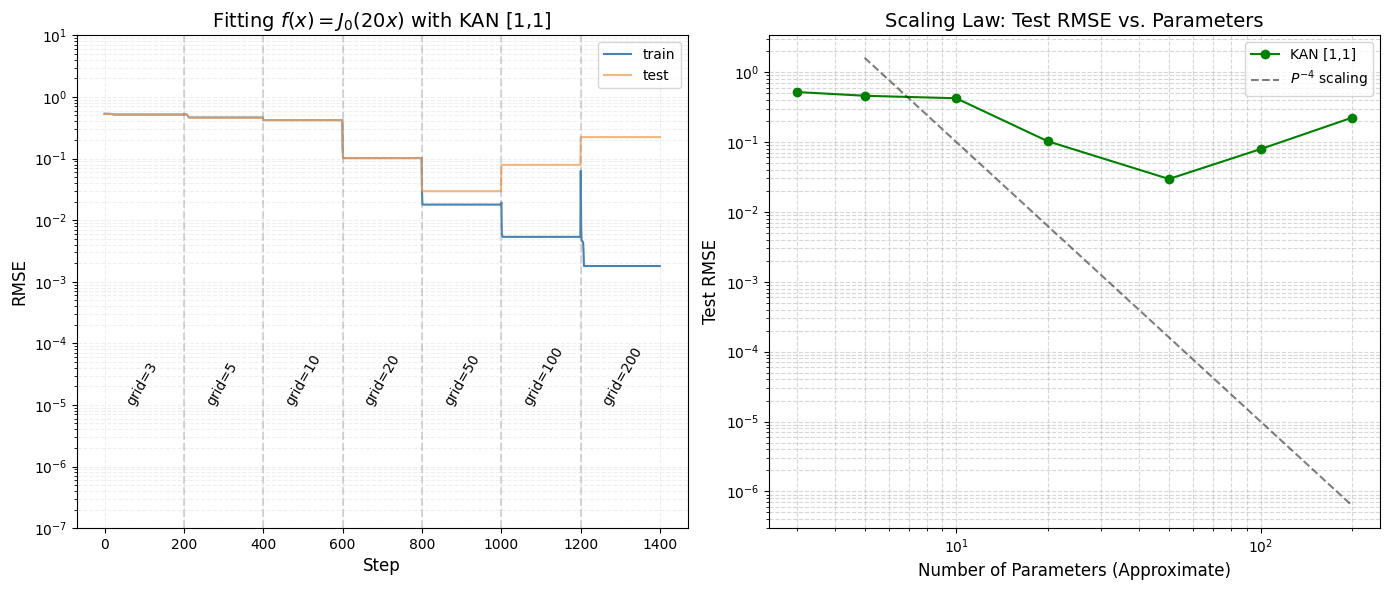

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kan import KAN, create_dataset

# Force CPU and float64 for mathematical stability during spline interpolation
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

# 1. Define the synthetic dataset: f(x) = J_0(20x)
# Note: n_var=1 because this is a 1D function
f = lambda x: torch.special.bessel_j0(20 * x[:, [0]])
dataset = create_dataset(f, n_var=1, train_num=1000, test_num=1000, device=device)

# 2. Experiment Configuration
# Expanded to 200. 7 grids * 200 steps = 1400 epochs total.
grids = [3, 5, 10, 20, 50, 100, 200]
steps_per_grid = 200

# 3. Initialize Model and Storage
# Architecture is [1, 1] for a 1D -> 1D mapping
model = KAN(width=[1, 1], grid=grids[0], k=3, seed=0, device=device)

train_rmse = []
test_rmse = []
final_test_rmse = []

# 4. Training Loop with Grid Extension
for g in grids:
    print(f"Training on grid size {g}...")
    if g != grids[0]:
        # Fine-grain the spline grids
        model = model.refine(g)

    # lamb=0.0 disables sparsity regularization so LBFGS focuses purely on MSE
    res = model.fit(dataset, opt="LBFGS", steps=steps_per_grid, lamb=0.0)

    # PyKAN natively returns MSE; we take sqrt for RMSE
    train_rmse.extend(np.sqrt(res['train_loss']))

    # Store test loss step-by-step for the first plot, and final loss for the second plot
    test_rmse_step = np.sqrt(res['test_loss'])
    test_rmse.extend(test_rmse_step)
    final_test_rmse.append(test_rmse_step[-1])

# 5. Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Loss vs Steps (Training Dynamics) ---
steps_total = np.arange(len(grids) * steps_per_grid)

axs[0].semilogy(steps_total, train_rmse, label='train', color='steelblue', linewidth=1.5)
axs[0].semilogy(steps_total, test_rmse, label='test', color='sandybrown', linewidth=1.5, alpha=0.8)

# Add grid text annotations and vertical dividing lines
for i, g in enumerate(grids):
    axs[0].text(i * steps_per_grid + 50, 1e-5, f'grid={g}', rotation=60, fontsize=10)
    if i > 0:
        axs[0].axvline(x=i * steps_per_grid, color='gray', linestyle='--', alpha=0.3)

axs[0].set_title(r'Fitting $f(x) = J_0(20x)$ with KAN [1,1]', fontsize=14)
axs[0].set_xlabel('Step', fontsize=12)
axs[0].set_ylabel('RMSE', fontsize=12)
axs[0].set_ylim(1e-7, 1e1)
axs[0].legend(loc='upper right')
axs[0].grid(True, which="both", ls="--", alpha=0.2)

# --- Plot 2: Loss vs Parameters (Scaling Laws) ---
G = np.array(grids)
# A [1,1] KAN has exactly 1 edge. Parameters = 1 * G
params_11 = 1 * G

axs[1].loglog(params_11, final_test_rmse, 'g-o', label='KAN [1,1]', markersize=6)

# Add a reference scaling line to see how steeply it learns (e.g., P^-4)
ref_line = 1e3 * params_11**(-4.0)
axs[1].loglog(params_11[1:], ref_line[1:], 'k--', alpha=0.5, label='$P^{-4}$ scaling')

axs[1].set_title(r'Scaling Law: Test RMSE vs. Parameters', fontsize=14)
axs[1].set_xlabel('Number of Parameters (Approximate)', fontsize=12)
axs[1].set_ylabel('Test RMSE', fontsize=12)
axs[1].grid(True, which="both", ls="--", alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()